In [172]:
import xarray as xr 
import numpy as np 
import cmaps as cmap 
import matplotlib.pyplot as plt
import scipy 

OMEGA = 7.292 * 10**-5

# To speed up processing (since SciPy is really slow re: coordinate reprojection), pick case number and height here
# This code could be adapted in the future to work with with three dimensional data...
# ...by modifying the rePoPolar function, but the goal here is to get something that works 
caseNum = 100
height = 2

In [ ]:
def rePoPolar(dataset, latitude, clon, clat, offset = 0, cov = False):
    x = dataset.longitude.values - clon.values
    y = dataset.latitude.values - clat.values
    x, y = np.meshgrid(x, y)

    R = 6371000
    cphi = np.cos(np.deg2rad(latitude.values))
    x = R * np.deg2rad(x) * cphi
    y = R * np.deg2rad(y)

    r = np.sqrt(x**2 + y**2)
    t = np.arctan2(y, x)

    rBins = np.linspace(0, 200000, 200)
    tBins = np.linspace(-np.pi, np.pi, 360)

    for i in range(len(tBins)):
            tBins[i] = tBins[i] + offset
            while tBins[i] <= (-1 * np.pi):
                tBins[i] = tBins[i] + (2 * np.pi)
            while tBins[i] >= np.pi:
                tBins[i] = tBins[i] - (2 * np.pi)

    R, T = np.meshgrid(rBins, tBins)
    newX, newY = R * np.cos(T), R * np.sin(T)
    if cov == False:
         mask = (np.isfinite(dataset.values).flatten()) & (np.isfinite(x).flatten()) & (np.isfinite(y).flatten())
    else:
         mask = (dataset.values.flatten() == 1) & (np.isfinite(x).flatten()) & (np.isfinite(y).flatten())

    gridded_data = scipy.interpolate.griddata((x.flatten()[mask], y.flatten()[mask]), dataset.values.flatten()[mask], (newX.flatten(), newY.flatten()), method='nearest')

    polar = xr.Dataset(
        {
            'polar': (('r', 'theta'), gridded_data.reshape(R.shape).transpose())
        },
        coords={
            'r': rBins,
            'theta': tBins
        }
    )
    print("Unique coverage after interp:", np.unique(polar['polar'].values))

    return polar['polar']


In [216]:
dataset = xr.open_dataset(r"C:\Users\deela\Downloads\tc_radar_v3m_2020_2024_xy_rel_swath_ships.nc").sel(num_cases = caseNum, height = height)
u = dataset['swath_earth_relative_eastward_wind']
v = dataset['swath_earth_relative_northward_wind']
lats = dataset['original_latitudes']
lons = dataset['original_longitudes']
clat = dataset['tc_center_latitudes']
clon = dataset['tc_center_longitudes']
dataset['coverage'] = xr.where(~np.isnan(u), 1, 0)
dataset['f'] = 2 * OMEGA * np.sin(np.deg2rad(lats))
f = dataset['f']
cov = dataset['coverage']

In [175]:
u['latitude'] = lats.values[:, 0]
u['longitude'] = lons.values[0, :]
v['latitude'] = lats.values[:, 0]
v['longitude'] = lons.values[0, :]
f['latitude'] = lats.values[:, 0]
f['longitude'] = lons.values[0, :]

Unique coverage after interp: [nan]


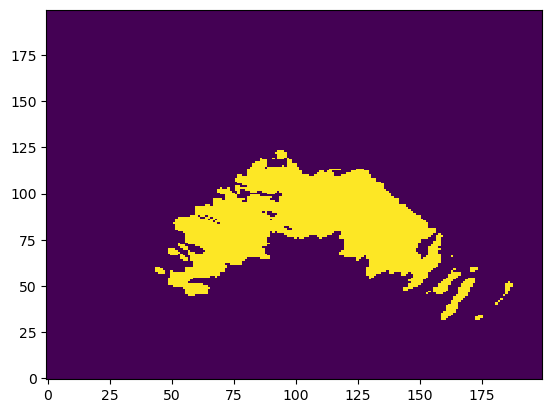

nan


C:\Users\deela\AppData\Local\Temp\ipykernel_102980\2215676781.py:9: RuntimeWarning: All-NaN axis encountered
  print(np.nanmax(coverage))
C:\Users\deela\AppData\Local\Temp\ipykernel_102980\2215676781.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(coverage.theta, coverage.r, coverage)


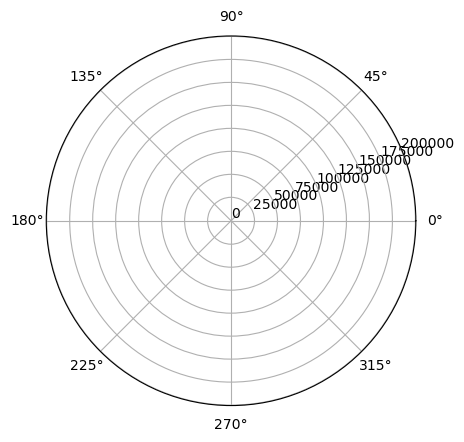

In [247]:
# test = rePoPolar(u, lats, clon, clat)
coverage = rePoPolar(cov, lats, clon, clat, offset = 0, cov = True)
plt.pcolormesh(u.longitude, u.latitude, cov)
plt.show()
plt.subplot(projection = 'polar')
# mask = (coverage['polar'].values == 0.5)
# data = test['polar'].values.copy()
# data[mask] = np.nan
print(np.nanmax(coverage))
plt.pcolormesh(coverage.theta, coverage.r, coverage)
plt.show()